### IMPORTING THE ESSENTIAL LIBRARY

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

### READING THE FILES

In [15]:
df1 = pd.read_csv("accident.csv")
df1.head()

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,ACCIDENT_TYPE_DESC,DAY_OF_WEEK,DAY_WEEK_DESC,DCA_CODE,DCA_DESC,LIGHT_CONDITION,...,NO_PERSONS_INJ_2,NO_PERSONS_INJ_3,NO_PERSONS_NOT_INJ,NO_PERSONS,POLICE_ATTEND,ROAD_GEOMETRY,ROAD_GEOMETRY_DESC,SEVERITY,SPEED_ZONE,RMA
0,T20160010202,2016-05-09,05:56:00,1,Collision with vehicle,2,Monday,120,HEAD ON (NOT OVERTAKING),4,...,1,1,0,2,1,5,Not at intersection,2,60,NaN
1,T20170017845,2017-09-17,05:45:00,1,Collision with vehicle,1,Sunday,121,RIGHT THROUGH,3,...,1,1,2,4,2,2,T intersection,2,80,Local Road
2,T20180005242,2018-03-19,18:24:00,4,Collision with a fixed object,2,Monday,171,LEFT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHICLE,2,...,3,0,0,3,1,1,Cross intersection,2,100,Local Road
3,T20190014171,2019-06-27,08:25:00,1,Collision with vehicle,4,Thursday,130,REAR END(VEHICLES IN SAME LANE),1,...,0,1,2,3,2,5,Not at intersection,3,80,Arterial Other
4,T20220017415,2022-07-28,05:40:00,1,Collision with vehicle,5,Thursday,134,LANE CHANGE RIGHT (NOT OVERTAKING),3,...,0,1,3,4,1,5,Not at intersection,3,80,Freeway


### CHECKING THE DATA 

In [16]:
print(df1.shape)
df1.isna().sum()

(195617, 23)


ACCIDENT_NO              0
ACCIDENT_DATE            0
ACCIDENT_TIME            0
ACCIDENT_TYPE            0
ACCIDENT_TYPE_DESC       0
DAY_OF_WEEK              0
DAY_WEEK_DESC            0
DCA_CODE                 0
DCA_DESC                 0
LIGHT_CONDITION          0
NODE_ID                  0
NO_OF_VEHICLES           0
NO_PERSONS_KILLED        0
NO_PERSONS_INJ_2         0
NO_PERSONS_INJ_3         0
NO_PERSONS_NOT_INJ       0
NO_PERSONS               0
POLICE_ATTEND            0
ROAD_GEOMETRY            0
ROAD_GEOMETRY_DESC       0
SEVERITY                 0
SPEED_ZONE               0
RMA                   8775
dtype: int64

In [17]:
df1 = df1.dropna()
df1.isna().sum()

ACCIDENT_NO           0
ACCIDENT_DATE         0
ACCIDENT_TIME         0
ACCIDENT_TYPE         0
ACCIDENT_TYPE_DESC    0
DAY_OF_WEEK           0
DAY_WEEK_DESC         0
DCA_CODE              0
DCA_DESC              0
LIGHT_CONDITION       0
NODE_ID               0
NO_OF_VEHICLES        0
NO_PERSONS_KILLED     0
NO_PERSONS_INJ_2      0
NO_PERSONS_INJ_3      0
NO_PERSONS_NOT_INJ    0
NO_PERSONS            0
POLICE_ATTEND         0
ROAD_GEOMETRY         0
ROAD_GEOMETRY_DESC    0
SEVERITY              0
SPEED_ZONE            0
RMA                   0
dtype: int64

In [20]:
df1.apply(lambda col : col.unique())

ACCIDENT_NO           [T20170017845, T20180005242, T20190014171, T20...
ACCIDENT_DATE         [2017-09-17, 2018-03-19, 2019-06-27, 2022-07-2...
ACCIDENT_TIME         [05:45:00, 18:24:00, 08:25:00, 05:40:00, 14:30...
ACCIDENT_TYPE                               [1, 4, 3, 2, 8, 7, 6, 5, 9]
ACCIDENT_TYPE_DESC    [Collision with vehicle, Collision with a fixe...
DAY_OF_WEEK                                    [1, 2, 4, 5, 3, 7, 6, 0]
DAY_WEEK_DESC         [Sunday, Monday, Thursday, Wednesday, Tuesday,...
DCA_CODE              [121, 171, 130, 134, 173, 148, 108, 100, 116, ...
DCA_DESC              [RIGHT THROUGH, LEFT OFF CARRIAGEWAY INTO OBJE...
LIGHT_CONDITION                                   [3, 2, 1, 9, 5, 6, 4]
NODE_ID               [278858, 329728, 358996, 720773, 804929, 26296...
NO_OF_VEHICLES        [2, 1, 3, 4, 5, 6, 7, 8, 13, 21, 10, 9, 0, 14,...
NO_PERSONS_KILLED                                    [0, 1, 2, 5, 4, 3]
NO_PERSONS_INJ_2             [1, 3, 0, 2, 6, 4, 5, 7, 8, 11, 15,

### READING WEATHER FILES

In [22]:
df2 = pd.read_csv("Weather_cond.csv")
df2.head()

,_id,ACCIDENT_NO,ATMOSPH_COND,ATMOSPH_COND_SEQ,ATMOSPH_COND_DESC
0,1,T20150004025,1,1,Clear
1,2,T20170001571,1,1,Clear
2,3,T20200021227,1,1,Clear
3,4,T20160019213,1,1,Clear
4,5,T20170009392,1,1,Clear


In [23]:
df2.isna().sum()

_id                  0
ACCIDENT_NO          0
ATMOSPH_COND         0
ATMOSPH_COND_SEQ     0
ATMOSPH_COND_DESC    0
dtype: int64

### MERGING THE FILES

In [24]:
merged = df1.merge(df2, how='inner', left_on="ACCIDENT_NO", right_on="ACCIDENT_NO")
merged.head()

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,ACCIDENT_TYPE_DESC,DAY_OF_WEEK,DAY_WEEK_DESC,DCA_CODE,DCA_DESC,LIGHT_CONDITION,...,POLICE_ATTEND,ROAD_GEOMETRY,ROAD_GEOMETRY_DESC,SEVERITY,SPEED_ZONE,RMA,_id,ATMOSPH_COND,ATMOSPH_COND_SEQ,ATMOSPH_COND_DESC
0,T20170017845,2017-09-17,05:45:00,1,Collision with vehicle,1,Sunday,121,RIGHT THROUGH,3,...,2,2,T intersection,2,80,Local Road,285,1,1,Clear
1,T20180005242,2018-03-19,18:24:00,4,Collision with a fixed object,2,Monday,171,LEFT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHICLE,2,...,1,1,Cross intersection,2,100,Local Road,526,1,1,Clear
2,T20190014171,2019-06-27,08:25:00,1,Collision with vehicle,4,Thursday,130,REAR END(VEHICLES IN SAME LANE),1,...,2,5,Not at intersection,3,80,Arterial Other,416,9,0,Not known
3,T20220017415,2022-07-28,05:40:00,1,Collision with vehicle,5,Thursday,134,LANE CHANGE RIGHT (NOT OVERTAKING),3,...,1,5,Not at intersection,3,80,Freeway,547,1,1,Clear
4,T20240012799,2024-01-31,14:30:00,3,Struck animal,3,Wednesday,173,RIGHT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHICLE,1,...,2,5,Not at intersection,2,999,Local Road,301,9,0,Not known


In [26]:
merged.isna().sum()

ACCIDENT_NO           0
ACCIDENT_DATE         0
ACCIDENT_TIME         0
ACCIDENT_TYPE         0
ACCIDENT_TYPE_DESC    0
DAY_OF_WEEK           0
DAY_WEEK_DESC         0
DCA_CODE              0
DCA_DESC              0
LIGHT_CONDITION       0
NODE_ID               0
NO_OF_VEHICLES        0
NO_PERSONS_KILLED     0
NO_PERSONS_INJ_2      0
NO_PERSONS_INJ_3      0
NO_PERSONS_NOT_INJ    0
NO_PERSONS            0
POLICE_ATTEND         0
ROAD_GEOMETRY         0
ROAD_GEOMETRY_DESC    0
SEVERITY              0
SPEED_ZONE            0
RMA                   0
_id                   0
ATMOSPH_COND          0
ATMOSPH_COND_SEQ      0
ATMOSPH_COND_DESC     0
dtype: int64

In [27]:
merged.dtypes

ACCIDENT_NO           object
ACCIDENT_DATE         object
ACCIDENT_TIME         object
ACCIDENT_TYPE          int64
ACCIDENT_TYPE_DESC    object
DAY_OF_WEEK            int64
DAY_WEEK_DESC         object
DCA_CODE               int64
DCA_DESC              object
LIGHT_CONDITION        int64
NODE_ID                int64
NO_OF_VEHICLES         int64
NO_PERSONS_KILLED      int64
NO_PERSONS_INJ_2       int64
NO_PERSONS_INJ_3       int64
NO_PERSONS_NOT_INJ     int64
NO_PERSONS             int64
POLICE_ATTEND          int64
ROAD_GEOMETRY          int64
ROAD_GEOMETRY_DESC    object
SEVERITY               int64
SPEED_ZONE             int64
RMA                   object
_id                    int64
ATMOSPH_COND           int64
ATMOSPH_COND_SEQ       int64
ATMOSPH_COND_DESC     object
dtype: object

### Preprocessing the data

In [50]:
df = merged.copy()
# --- Parse datetime features ---
df["ACCIDENT_DATE"] = pd.to_datetime(df["ACCIDENT_DATE"], errors="coerce")
df["MONTH"] = df["ACCIDENT_DATE"].dt.month
df["HOUR"] = pd.to_datetime(
    df["ACCIDENT_TIME"], format="%H:%M:%S", errors="coerce"
).dt.hour

In [51]:
 #--- Encode ATMOSPH_COND_DESC (e.g. 'Clear', 'Raining') as a numeric category ---
# This preserves the meaningful weather label while making it ML-ready
df["ATMOSPH_COND_DESC"] = df["ATMOSPH_COND_DESC"].astype("category")
df["WEATHER_CAT"] = df["ATMOSPH_COND_DESC"].cat.codes  # -1 = NaN, 0+ = encoded label
print("Weather condition encoding:")
weather_map = dict(enumerate(df["ATMOSPH_COND_DESC"].cat.categories))
print(weather_map)

# --- Encode RMA (e.g. 'Local Road', 'Arterial') as a numeric category ---
df["RMA"] = df["RMA"].astype("category")
df["RMA_CAT"] = df["RMA"].cat.codes
print("\nRoad type (RMA) encoding:")
rma_map = dict(enumerate(df["RMA"].cat.categories))
print(rma_map)


Weather condition encoding:
{0: 'Clear', 1: 'Dust', 2: 'Fog', 3: 'Not known', 4: 'Raining', 5: 'Smoke', 6: 'Snowing', 7: 'Strong winds'}

Road type (RMA) encoding:
{0: 'Arterial Highway', 1: 'Arterial Other', 2: 'Freeway', 3: 'Local Road', 4: 'Non Arterial'}


In [52]:
# --- Drop columns: identifiers, raw text desc duplicates, and outcome-leaking columns ---
# ATMOSPH_COND_DESC and RMA are now encoded as WEATHER_CAT and RMA_CAT above
drop_cols = [
    "ACCIDENT_NO", "ACCIDENT_DATE", "ACCIDENT_TIME",   # identifiers / raw date
    "ACCIDENT_TYPE_DESC", "DAY_WEEK_DESC", "DCA_DESC",  # pure text duplicates of coded cols
    "ROAD_GEOMETRY_DESC",                               # text duplicate of ROAD_GEOMETRY
    "ATMOSPH_COND_DESC", "RMA",                         # replaced by WEATHER_CAT & RMA_CAT
    "_id",                                              # row identifier — no predictive value
    # Outcome-leaking columns — directly encode the crash result, must be removed
    "NO_PERSONS_KILLED", "NO_PERSONS_INJ_2",
    "NO_PERSONS_INJ_3", "NO_PERSONS_NOT_INJ", "NO_PERSONS"
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

In [53]:
# --- Impute missing numeric values with median ---
# Drop any all-NaN numeric columns before imputing
num_cols = df.select_dtypes(include=np.number).columns.tolist()
valid_num_cols = [c for c in num_cols if not df[c].isnull().all()]

imputer = SimpleImputer(strategy="median")
imputed_array = imputer.fit_transform(df[valid_num_cols])
df[valid_num_cols] = pd.DataFrame(imputed_array, columns=valid_num_cols, index=df.index)

print(f"\nPreprocessing complete. Shape: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")


Preprocessing complete. Shape: (178134, 16)
Remaining columns: ['ACCIDENT_TYPE', 'DAY_OF_WEEK', 'DCA_CODE', 'LIGHT_CONDITION', 'NODE_ID', 'NO_OF_VEHICLES', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SEVERITY', 'SPEED_ZONE', 'ATMOSPH_COND', 'ATMOSPH_COND_SEQ', 'MONTH', 'HOUR', 'WEATHER_CAT', 'RMA_CAT']


In [54]:
print(df.shape)
df.dtypes

(178134, 16)


ACCIDENT_TYPE       float64
DAY_OF_WEEK         float64
DCA_CODE            float64
LIGHT_CONDITION     float64
NODE_ID             float64
NO_OF_VEHICLES      float64
POLICE_ATTEND       float64
ROAD_GEOMETRY       float64
SEVERITY            float64
SPEED_ZONE          float64
ATMOSPH_COND        float64
ATMOSPH_COND_SEQ    float64
MONTH               float64
HOUR                float64
WEATHER_CAT         float64
RMA_CAT             float64
dtype: object

In [55]:
df.isna().sum()

ACCIDENT_TYPE       0
DAY_OF_WEEK         0
DCA_CODE            0
LIGHT_CONDITION     0
NODE_ID             0
NO_OF_VEHICLES      0
POLICE_ATTEND       0
ROAD_GEOMETRY       0
SEVERITY            0
SPEED_ZONE          0
ATMOSPH_COND        0
ATMOSPH_COND_SEQ    0
MONTH               0
HOUR                0
WEATHER_CAT         0
RMA_CAT             0
dtype: int64

In [65]:
print(df["SPEED_ZONE"].value_counts().sort_index())
print(f"\nTotal unique values: {df['SPEED_ZONE'].nunique()}")

SPEED_ZONE
30.0       332
40.0     11495
50.0     29797
60.0     59439
70.0     11432
75.0        21
80.0     26963
90.0       487
100.0    23835
110.0     1966
Name: count, dtype: int64

Total unique values: 10


In [66]:
df["SPEED_ZONE"] = df["SPEED_ZONE"].replace({777.0: np.nan, 888.0: np.nan, 999.0: np.nan})

### SEE HOW NUMERICAL FEATURES ARE DISTRIBUTED ACROSS SEVERITY LEVEL

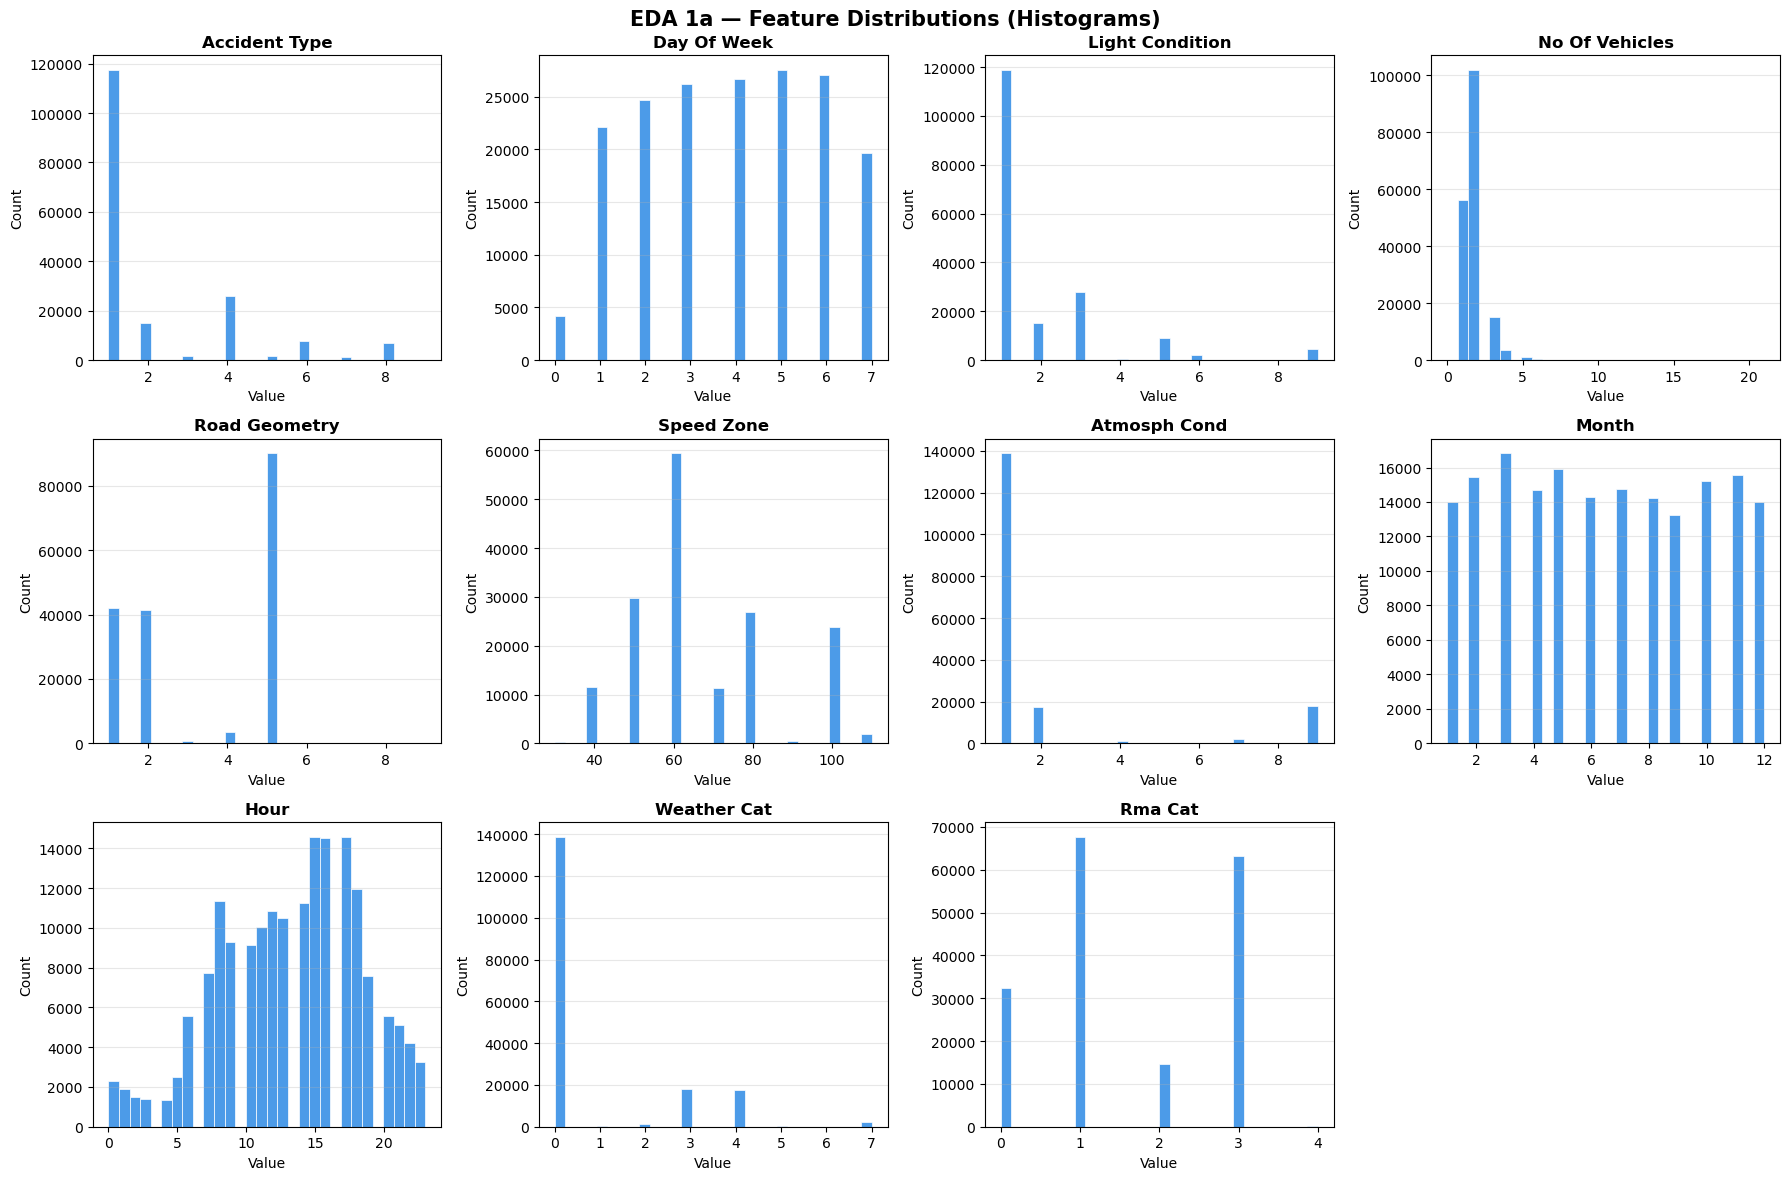

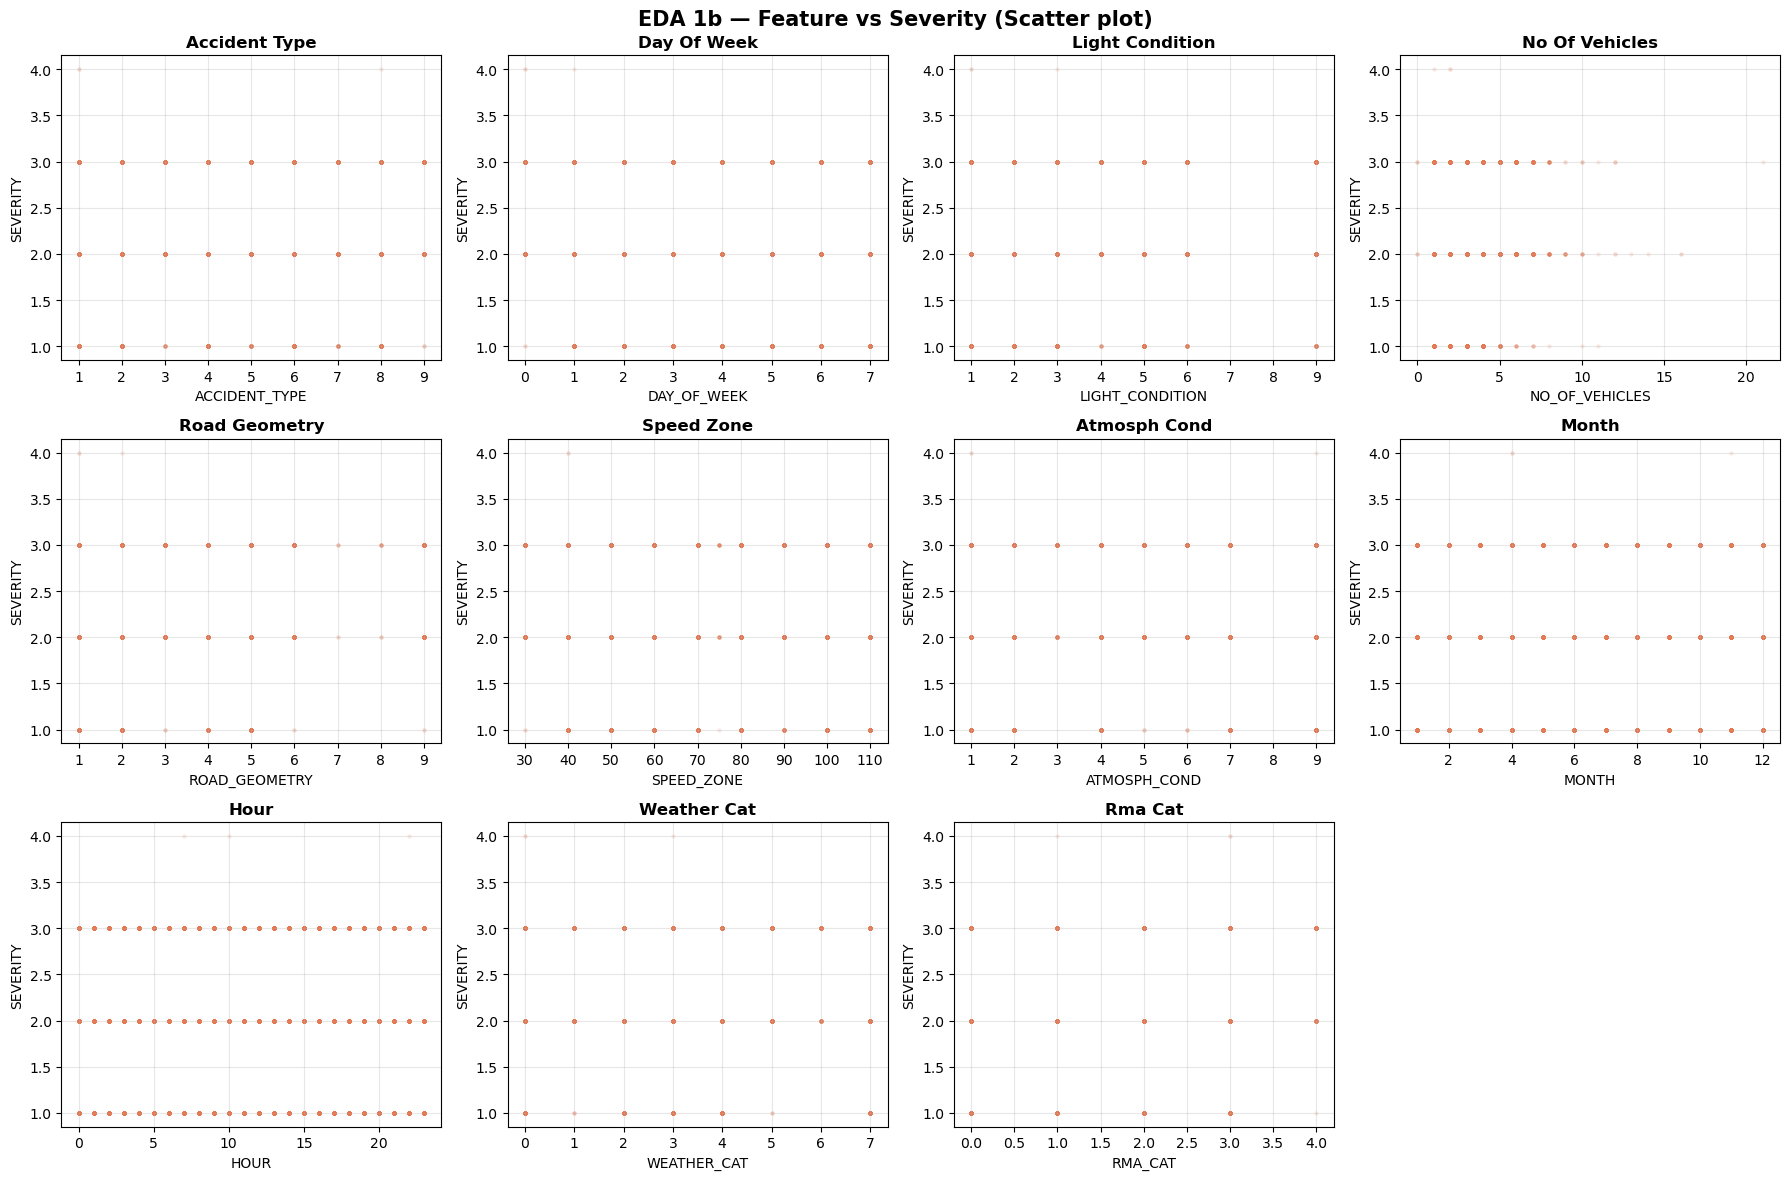

In [67]:
features = [
    "ACCIDENT_TYPE", "DAY_OF_WEEK", "LIGHT_CONDITION",
    "NO_OF_VEHICLES", "ROAD_GEOMETRY", "SPEED_ZONE",
    "ATMOSPH_COND", "MONTH", "HOUR", "WEATHER_CAT", "RMA_CAT"
]
features = [f for f in features if f in df.columns]

# ── Histograms: distribution of each feature ────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("EDA 1a — Feature Distributions (Histograms)", fontsize=15, fontweight="bold")

for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat].dropna(), bins=30, color="#4C9BE8", edgecolor="white", linewidth=0.5)
    ax.set_title(feat.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)

for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("eda_1a_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Scatter plots: each feature vs SEVERITY ─────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("EDA 1b — Feature vs Severity (Scatter plot)", fontsize=15, fontweight="bold")

for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df[feat], df["SEVERITY"], alpha=0.1, s=5, color="#E8754C")
    ax.set_title(feat.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("SEVERITY")
    ax.grid(alpha=0.3)

for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("eda_1b_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

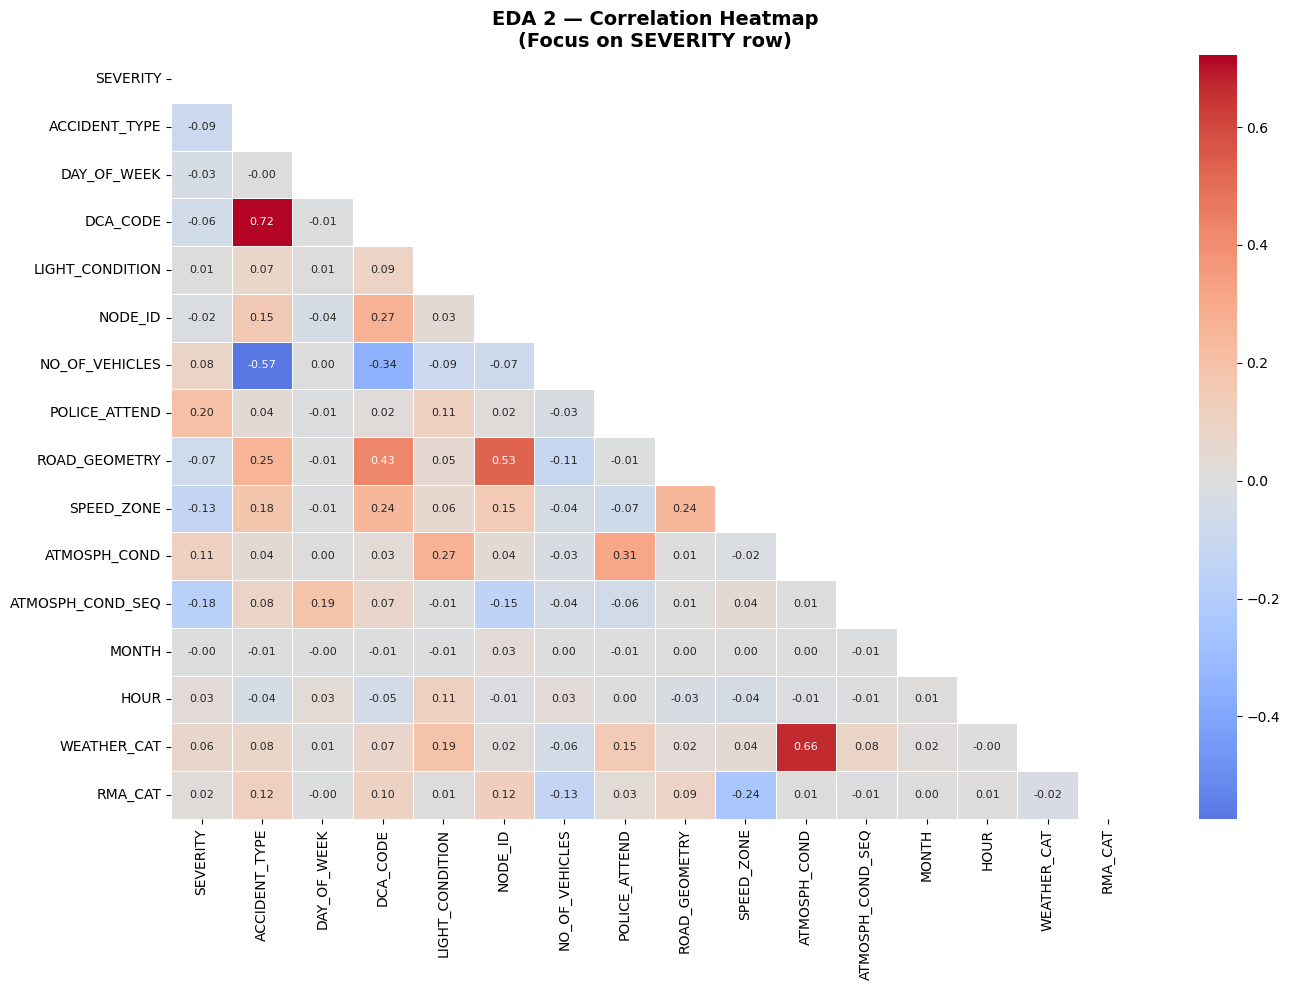

🔍 Top 8 features correlated with SEVERITY:


,Feature,|Correlation|
0,POLICE_ATTEND,0.198765
1,ATMOSPH_COND_SEQ,0.176540
2,SPEED_ZONE,0.126354
3,ATMOSPH_COND,0.110897
4,ACCIDENT_TYPE,0.089524
5,NO_OF_VEHICLES,0.083812
6,ROAD_GEOMETRY,0.067654
7,WEATHER_CAT,0.064015


Saved: eda_2_correlation.png


In [68]:
num_df = df.select_dtypes(include=np.number)

# Put SEVERITY first for easy reading
cols = ["SEVERITY"] + [c for c in num_df.columns if c != "SEVERITY"]
corr = num_df[cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title(
    "EDA 2 — Correlation Heatmap\n(Focus on SEVERITY row)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("eda_2_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the top correlating features with SEVERITY
top_corr = (
    corr["SEVERITY"]
    .drop("SEVERITY")
    .abs()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
    .rename(columns={"index": "Feature", "SEVERITY": "|Correlation|"})
)
print("🔍 Top 8 features correlated with SEVERITY:")
display(top_corr)
print("Saved: eda_2_correlation.png")

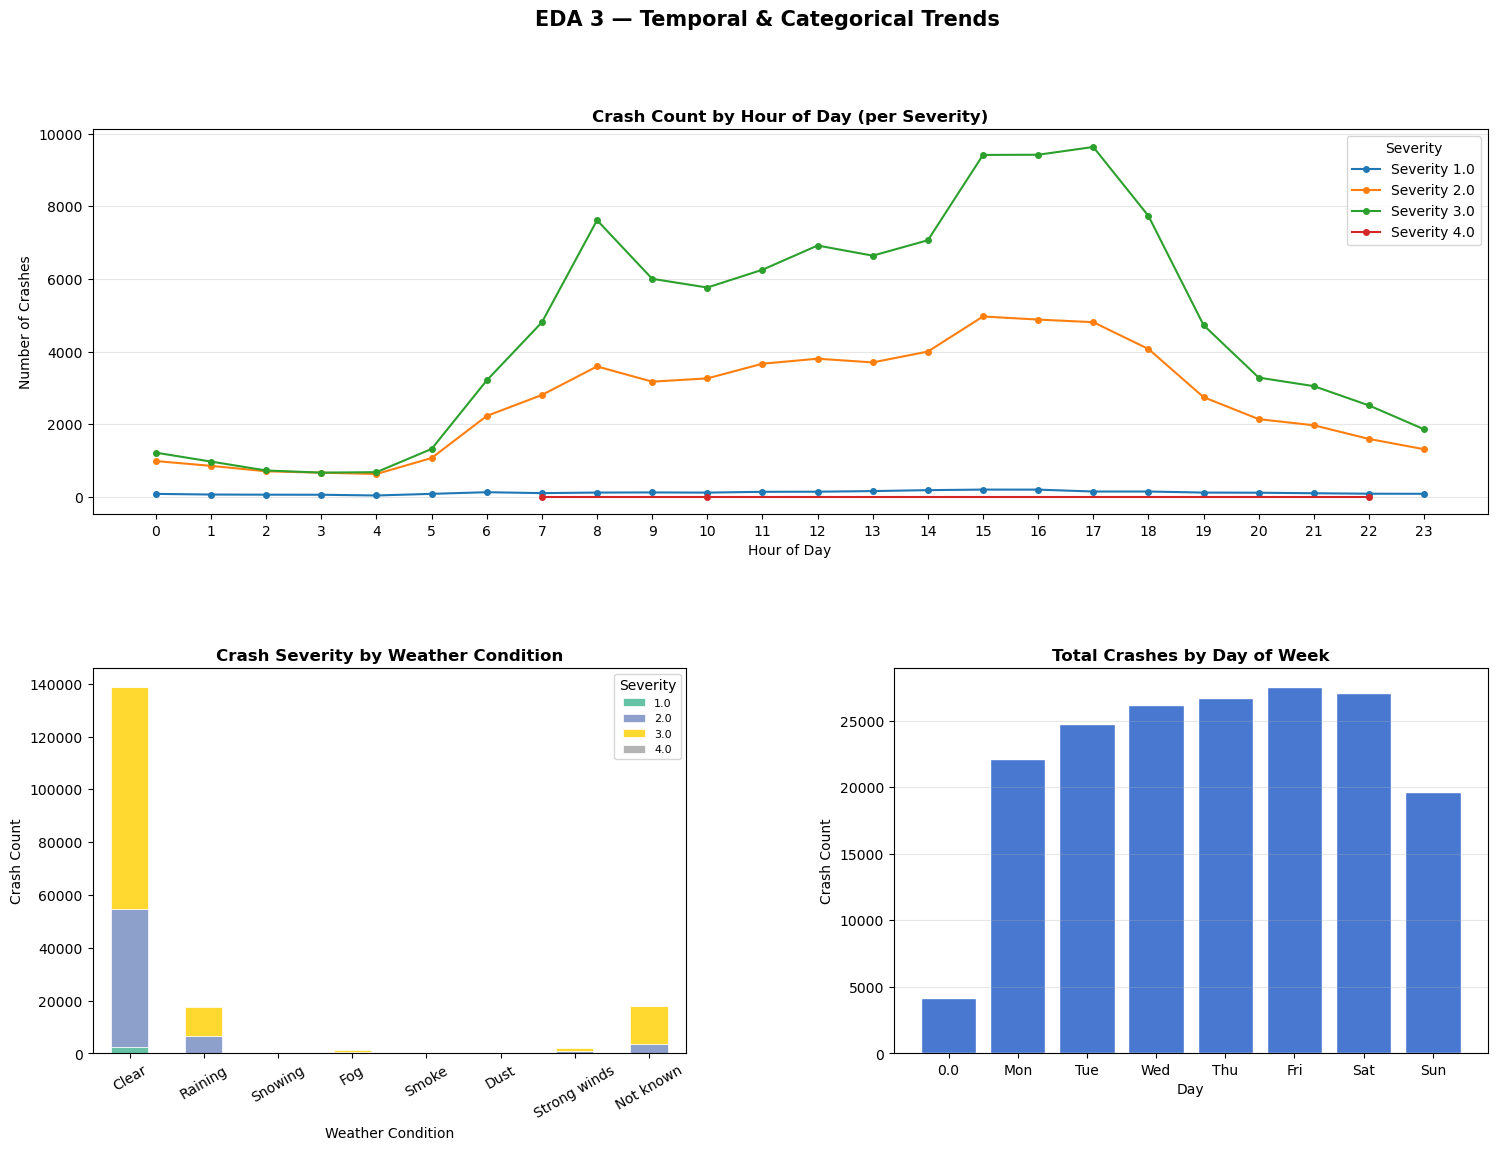

Saved: eda_3_trends.png


In [70]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("EDA 3 — Temporal & Categorical Trends", fontsize=15, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot A: Crashes by Hour of Day ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
hour_sev = (
    df.groupby(["HOUR", "SEVERITY"])
    .size()
    .reset_index(name="COUNT")
)
palette = sns.color_palette("tab10", n_colors=df["SEVERITY"].nunique())
for i, sev in enumerate(sorted(df["SEVERITY"].unique())):
    sub = hour_sev[hour_sev["SEVERITY"] == sev]
    ax1.plot(
        sub["HOUR"], sub["COUNT"],
        marker="o", markersize=4,
        label=f"Severity {sev}", color=palette[i]
    )
ax1.set_title("Crash Count by Hour of Day (per Severity)", fontweight="bold")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Number of Crashes")
ax1.legend(title="Severity", loc="upper right")
ax1.set_xticks(range(0, 24))
ax1.grid(axis="y", alpha=0.3)

# ── Plot B: Crash Severity by Weather Condition ─────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

# Build a code → description mapping from the data
code_to_desc = (
    merged[["ATMOSPH_COND", "ATMOSPH_COND_DESC"]]
    .drop_duplicates()
    .sort_values("ATMOSPH_COND")
    .set_index("ATMOSPH_COND")["ATMOSPH_COND_DESC"]
    .to_dict()
)

weather_sev = (
    df.groupby(["ATMOSPH_COND", "SEVERITY"])
    .size()
    .unstack(fill_value=0)
)
# Replace numeric index with description labels
weather_sev.index = [code_to_desc.get(c, str(c)) for c in weather_sev.index]

weather_sev.plot(
    kind="bar", stacked=True, ax=ax2,
    colormap="Set2", edgecolor="white", linewidth=0.5
)
ax2.set_title("Crash Severity by Weather Condition", fontweight="bold")
ax2.set_xlabel("Weather Condition")
ax2.set_ylabel("Crash Count")
ax2.legend(title="Severity", fontsize=8)
ax2.tick_params(axis="x", rotation=30)  # rotate so labels don't overlap

# ── Plot C: Crashes by Day of Week ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
day_labels = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
day_counts = df["DAY_OF_WEEK"].value_counts().sort_index()
ax3.bar(
    [day_labels.get(d, str(d)) for d in day_counts.index],
    day_counts.values,
    color=sns.color_palette("muted")[0],
    edgecolor="white"
)
ax3.set_title("Total Crashes by Day of Week", fontweight="bold")
ax3.set_xlabel("Day")
ax3.set_ylabel("Crash Count")
ax3.grid(axis="y", alpha=0.3)

plt.savefig("eda_3_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_3_trends.png")

### DEFINE FEATURES AND TARGET VARIABLES

In [76]:
df["SPEED_ZONE"] = df["SPEED_ZONE"].fillna(df["SPEED_ZONE"].median())

In [77]:
feature_cols = [
    "ACCIDENT_TYPE", "DAY_OF_WEEK", "DCA_CODE",
    "LIGHT_CONDITION", "NO_OF_VEHICLES", "POLICE_ATTEND",
    "ROAD_GEOMETRY", "SPEED_ZONE", "ATMOSPH_COND",
    "ATMOSPH_COND_SEQ", "MONTH", "HOUR",
    "WEATHER_CAT",   # encoded ATMOSPH_COND_DESC: Clear, Rain, Fog, etc.
    "RMA_CAT"        # encoded RMA: Local Road, Arterial, Freeway, etc.
]
# Keep only columns that exist in the dataframe
feature_cols = [f for f in feature_cols if f in df.columns]

X = df[feature_cols]
y = df["SEVERITY"]

print(f"Features used     : {feature_cols}")
print(f"Number of features: {len(feature_cols)}")
print(f"Number of samples : {len(X)}")
print(f"Severity classes  : {sorted(y.unique())}")
print(f"\nClass distribution:")
display(y.value_counts().sort_index().rename("Count").to_frame())

Features used     : ['ACCIDENT_TYPE', 'DAY_OF_WEEK', 'DCA_CODE', 'LIGHT_CONDITION', 'NO_OF_VEHICLES', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SPEED_ZONE', 'ATMOSPH_COND', 'ATMOSPH_COND_SEQ', 'MONTH', 'HOUR', 'WEATHER_CAT', 'RMA_CAT']
Number of features: 14
Number of samples : 178134
Severity classes  : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

Class distribution:


,Count
SEVERITY,
1.0,2890
2.0,63696
3.0,111545
4.0,3


### TEST TRAIN SPLIT

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")

Training set size : 142507 samples
Test set size     : 35627 samples


### MODEL 1: LOGISTIC REGRESSION

In [79]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)
lr_pred = lr_model.predict(X_test_sc)

lr_cv = cross_val_score(lr_model, X_train_sc, y_train, cv=5, scoring="f1_weighted")

print("Classification Report — Logistic Regression")
print("=" * 50)
print(classification_report(y_test, lr_pred, zero_division=0))
print(f"CV F1 (weighted): {lr_cv.mean():.3f} ± {lr_cv.std():.3f}")

Classification Report — Logistic Regression
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       578
         2.0       0.53      0.29      0.38     12739
         3.0       0.68      0.87      0.76     22309
         4.0       0.00      0.00      0.00         1

    accuracy                           0.65     35627
   macro avg       0.30      0.29      0.28     35627
weighted avg       0.61      0.65      0.61     35627

CV F1 (weighted): 0.612 ± 0.003


### MODEL 2: RANDOM FOREST

In [80]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="f1_weighted")

print("Classification Report — Random Forest")
print("=" * 50)
print(classification_report(y_test, rf_pred, zero_division=0))
print(f"CV F1 (weighted): {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")

Classification Report — Random Forest
              precision    recall  f1-score   support

         1.0       0.15      0.03      0.04       578
         2.0       0.50      0.41      0.45     12739
         3.0       0.69      0.78      0.73     22309
         4.0       0.00      0.00      0.00         1

    accuracy                           0.64     35627
   macro avg       0.34      0.30      0.31     35627
weighted avg       0.62      0.64      0.62     35627

CV F1 (weighted): 0.621 ± 0.003


### MODEL 3 : GRADIENT BOOSTING

In [81]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_cv = cross_val_score(gb_model, X_train, y_train, cv=5, scoring="f1_weighted")

print("Classification Report — Gradient Boosting")
print("=" * 50)
print(classification_report(y_test, gb_pred, zero_division=0))
print(f"CV F1 (weighted): {gb_cv.mean():.3f} ± {gb_cv.std():.3f}")

Classification Report — Gradient Boosting
              precision    recall  f1-score   support

         1.0       0.25      0.01      0.01       578
         2.0       0.55      0.39      0.45     12739
         3.0       0.70      0.84      0.76     22309
         4.0       0.00      0.00      0.00         1

    accuracy                           0.66     35627
   macro avg       0.37      0.31      0.31     35627
weighted avg       0.64      0.66      0.64     35627

CV F1 (weighted): 0.638 ± 0.002


### Confusion Matrices

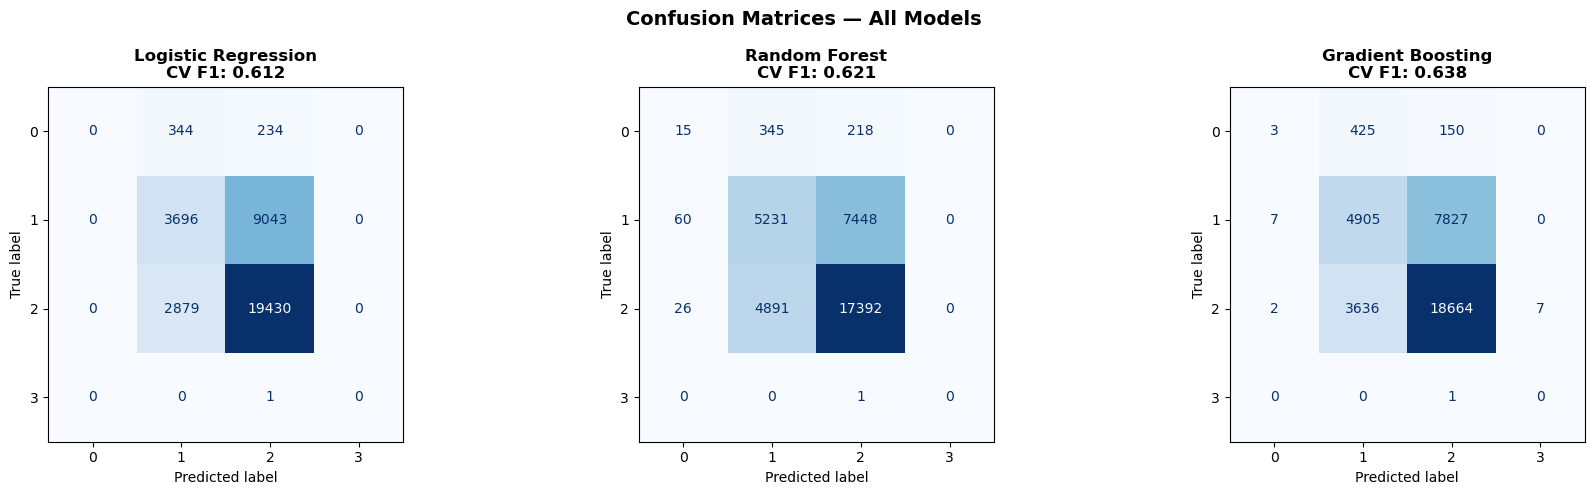

Saved: ml_confusion_matrices.png


In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")

model_results = [
    ("Logistic Regression", lr_pred, lr_cv.mean()),
    ("Random Forest",       rf_pred, rf_cv.mean()),
    ("Gradient Boosting",   gb_pred, gb_cv.mean()),
]

for ax, (name, y_pred, cv_score) in zip(axes, model_results):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nCV F1: {cv_score:.3f}", fontweight="bold")

plt.tight_layout()
plt.savefig("ml_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ml_confusion_matrices.png")

### FEATURE IMPORTANCE

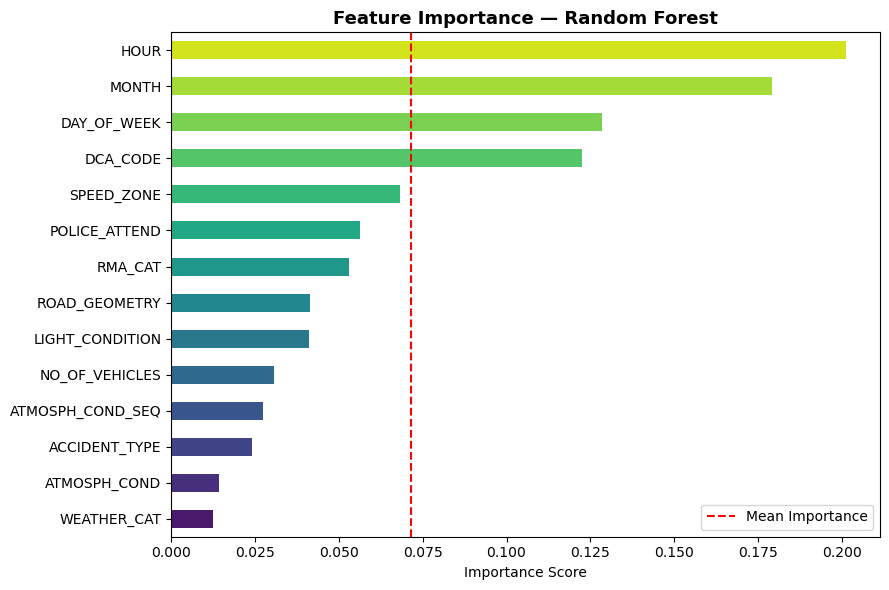

Saved: ml_feature_importance.png


In [83]:
importances = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette("viridis", len(importances))
importances.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importance — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.axvline(x=importances.mean(), color="red", linestyle="--", linewidth=1.5, label="Mean Importance")
ax.legend()
plt.tight_layout()
plt.savefig("ml_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ml_feature_importance.png")

### SUMMARY

In [86]:
summary = pd.DataFrame([
    {"Model": "Logistic Regression", "CV F1 (weighted)": round(lr_cv.mean(), 4), "Std": round(lr_cv.std(), 4)},
    {"Model": "Random Forest",       "CV F1 (weighted)": round(rf_cv.mean(), 4), "Std": round(rf_cv.std(), 4)},
    {"Model": "Gradient Boosting",   "CV F1 (weighted)": round(gb_cv.mean(), 4), "Std": round(gb_cv.std(), 4)},
]).sort_values("CV F1 (weighted)", ascending=False).reset_index(drop=True)

summary.index += 1  # rank from 1
print("Model Comparison (ranked by CV F1):")
display(summary)

best = summary.iloc[0]["Model"]
print(f"\nBest model: {best}")

Model Comparison (ranked by CV F1):


,Model,CV F1 (weighted),Std
1,Gradient Boosting,0.6376,0.0018
2,Random Forest,0.6213,0.0030
3,Logistic Regression,0.6117,0.0025



Best model: Gradient Boosting
